# Tema 3 - Algoritmos para la optimización en espacios de alta dimensionalidad

Las librerías que se van a emplear en los ejercicios son:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random as rm
from itertools import permutations
import copy

Establecemos los colores a emplear:

In [2]:
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#1b0033",
    "axes.facecolor": "#1b0033",
    "axes.edgecolor": "#ff71ce",
    "axes.labelcolor": "#ff71ce",
    "xtick.color": "#01cdfe",
    "ytick.color": "#01cdfe",
    "grid.color": "#05ffa1",
    "text.color": "#ff71ce",
    "font.family": "monospace"
})

## Primera actividad guiada
En este ejercicio se nos pide implementar numéricamente un algoritmo de "simulated annealing" para la resolución del TSP:
1. Partiendo del código proporcionado parcialmente implementado implementar las perturbaciones "random", "swap" e "inverse".
2. Realizar un estudio cualitativo de la influencia de los distintos parámetros del "cooling schedule" en la solución final y los tiempos de cálculo.

### Resolución
En primer lugar vamos a reimplementar el generador de Problemas del Viajante Euclidianos que hicimos en el primer tema:

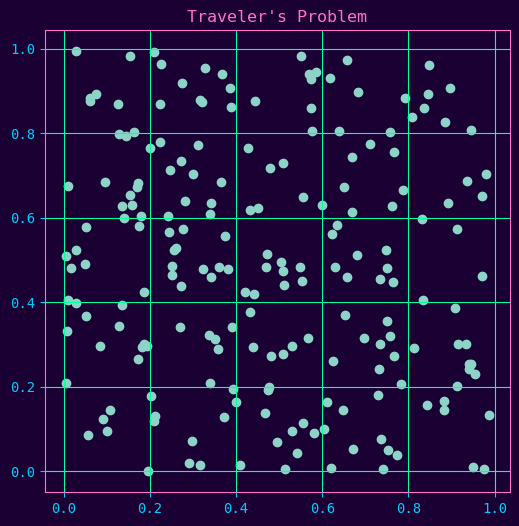

In [3]:
def generate_tsp_problem(num_cities):
    x_pos = []
    y_pos = []
    distances = []
    for i in range(num_cities):
        distances.append([0]*num_cities)

    for i in range(num_cities):
        x_pos.append(rm.random())
        y_pos.append(rm.random())

    for i in range(0, num_cities):
        for j in range(i, num_cities):
            distances[i][j] = np.sqrt(pow(x_pos[i]-x_pos[j],2) + pow(y_pos[i]-y_pos[j],2))
            distances[j][i] = distances[i][j]

    return x_pos, y_pos, distances

def plot_tsp_problem(x_pos, y_pos, routes=None):
    plt.figure(figsize=(6, 6))

    if routes is not None:
        xs = [x_pos[i] for i in routes]
        ys = [y_pos[i] for i in routes]

        plt.scatter(xs, ys)
        plt.plot(xs, ys, marker='o')  # draw the path

        for k in range(len(routes)):
            plt.text(xs[k] + 0.01, ys[k] + 0.01, str(k), fontsize=9)

        plt.title("Traveler's Journey")
    else:
        plt.scatter(x_pos, y_pos)
        plt.title("Traveler's Problem")

    plt.grid(True)
    plt.show()

x,y,distances = generate_tsp_problem(200)
plot_tsp_problem(x,y)

def closest_neighbour(distances):
    best_route = []
    for initial_city in range(len(distances)):
        total_distance = len(distances) * 12
        current_city = initial_city
        total_distance_try = 0
        exclude = [initial_city]
        for i in range(len(distances)-1):
            excluding_filter = [distances[current_city][j] for j in exclude]
            total_distance_try = total_distance_try + min(x for x in distances[current_city] if x not in excluding_filter)
            current_city = distances[current_city].index(min(x for x in distances[current_city] if x not in excluding_filter))
            exclude.append(current_city)
        total_distance_try = total_distance_try + distances[initial_city][current_city]

        if total_distance > total_distance_try:
            total_distance = total_distance_try
            best_route = exclude + [initial_city]
    return total_distance, best_route

A continuación vamos a generar una función para poder implementar cada uno de los métodos de perturbación previamente mencionados, siendo estos:
- "Randomize", el cual ordena de manera aleatoria la lista de ciudades.

- "Swap", el cual devuelve la lista de ciudades intercambiando la posición de dos números con índices escogidos al azar.

- "Inverse", el cual devuelve la lista de ciudades pero invirtiendo una sección aleatoria de todo el array (selecciona dos posiciones al azar e invierte las posiciones entre estas).

Además de esto vamos a crear una función que suma la distancia total entre las ciudades de una ruta determinada a partir de la ruta y de la matriz de distancias generada para el problema TSP.

In [4]:
def randomize(route):
    rm.shuffle(route)
    return route

def swap(route):
    while True:
        first_integer = rm.randint(0,len(route)-1)
        second_integer = rm.randint(0,len(route)-1)
        if first_integer != second_integer: break
    new_route = copy.copy(route)
    new_route[first_integer] = route[second_integer]
    new_route[second_integer] = route[first_integer]
    return new_route

def inverse(route):
    new_route = copy.copy(route)
    while True:
        first_integer = rm.randint(0,len(route)-1)
        second_integer = rm.randint(0,len(route)-1)
        if first_integer != second_integer and first_integer < second_integer: break
    new_route[first_integer:second_integer] = reversed(route[first_integer:second_integer])
    return new_route

def evaluate_distance(route,distances):
    total_distance = 0
    for i in range(len(route)-1):
        total_distance = total_distance + distances[route[i]][route[i+1]]
    total_distance = total_distance + distances[route[0]][route[-1]]

    return total_distance

Ahora vamos a implementar el "simulated annealing" siguiendo el siguiente pseudocódigo provisto en el temario:
```
Input:
    S          ← solución inicial
    C(x)       ← función de coste
    T          ← temperatura inicial
Output:
    S_best     ← solución aproximada óptima
while not frozen(T) do
    while not equilibrium(T) do
        S_new ← perturb(S)
        if C(S_new) < C(S) then
            S ← S_new
        else if accept_worse(C(S_new), C(S), T) then
            S ← S_new
        end if
    end while
    T ← reduce_temperature(T)
end while
return S
```

Vamos a establecer los siguientes parámetros de entrada:
- Temperatura inicial
- Alpha (disminución porcentual por iteración de la temperatura)
- Número de iteraciones de termalización
- Temperatura mínima
- Matriz de distancias
- Método de aleatorización de la ruta (0 para randomize, 1 para swap, 2 para inverse)


In [5]:
def simulated_annealing(initial_temperature, alpha, number_of_iterations_of_thermalization, minimum_temperature, distances, aleatorization_method, route = None):
    total_distance_array = []
    temperature_array = []
    if route == None:
        route=list(range(len(distances[0])))
    temperature = initial_temperature
    while temperature > minimum_temperature:
        total_distance = evaluate_distance(route,distances)
        for _ in range(number_of_iterations_of_thermalization):
            if aleatorization_method == 0: new_route = randomize(route)
            elif aleatorization_method == 1: new_route = swap(route)
            elif aleatorization_method == 2: new_route = inverse(route)
            new_total_distance  = evaluate_distance(new_route,distances)
            delta = new_total_distance - total_distance
            if (delta < 0) or (rm.random() < np.exp(-delta/temperature)):
                route, total_distance = new_route, new_total_distance
                total_distance_array.append(total_distance)
                temperature_array.append(temperature)
        temperature = temperature*alpha
    route.append(route[0])

    return total_distance, route, total_distance_array, temperature_array

Introducimos las variables a emplear para los distintos problemas y escribimos cuatro secciones distintas. La primera se dedicará al TSP resuelto por el método de vecinos más cercanos y las 3 siguientes por los métodos determinados anteriormente:

In [6]:
initial_temperature = 10
alpha = 0.99
number_of_iterations_of_thermalization = 100
minimum_temperature = 10**-6

14.047642269920996
[199, 19, 169, 155, 171, 173, 137, 16, 56, 48, 111, 74, 146, 103, 163, 98, 176, 179, 46, 153, 106, 8, 58, 110, 7, 124, 108, 129, 34, 191, 174, 53, 80, 86, 3, 175, 162, 144, 150, 94, 149, 6, 55, 21, 101, 28, 40, 59, 23, 17, 78, 92, 32, 68, 64, 63, 184, 188, 148, 81, 180, 52, 126, 62, 18, 54, 13, 120, 36, 131, 159, 164, 20, 65, 90, 140, 170, 115, 161, 195, 79, 96, 69, 100, 84, 116, 166, 26, 14, 133, 196, 182, 135, 167, 190, 93, 67, 88, 87, 107, 99, 104, 75, 151, 139, 49, 194, 31, 1, 141, 72, 186, 38, 60, 15, 154, 143, 117, 85, 160, 9, 158, 119, 76, 118, 4, 168, 41, 134, 145, 50, 112, 152, 185, 66, 142, 136, 138, 61, 114, 25, 29, 193, 71, 113, 24, 70, 45, 2, 192, 30, 165, 33, 10, 57, 0, 97, 35, 83, 39, 44, 89, 177, 82, 132, 172, 189, 156, 181, 197, 77, 122, 130, 121, 95, 109, 27, 125, 183, 5, 91, 47, 11, 128, 147, 198, 157, 102, 178, 73, 51, 12, 123, 43, 22, 187, 127, 37, 42, 105, 199]


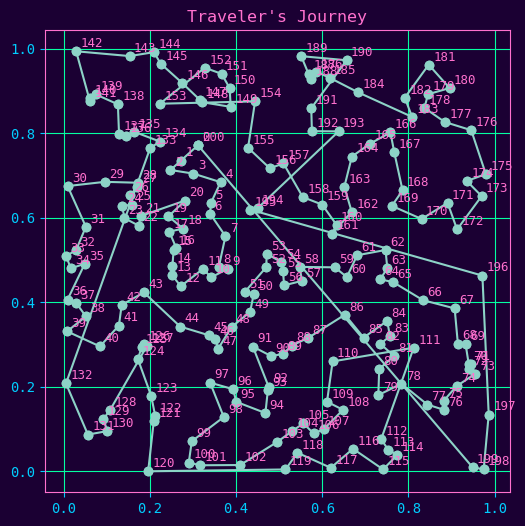

In [7]:
total_distance_cn, route_cn = closest_neighbour(distances)
print(total_distance_cn)
print(route_cn)
plot_tsp_problem(x, y, route_cn)

93.3211609337745
[28, 69, 184, 5, 189, 51, 126, 58, 74, 162, 64, 19, 39, 194, 36, 191, 163, 134, 37, 123, 26, 161, 65, 82, 4, 21, 2, 119, 6, 102, 136, 147, 173, 153, 172, 12, 175, 50, 178, 156, 10, 144, 32, 89, 186, 62, 129, 33, 20, 92, 88, 97, 78, 183, 38, 49, 177, 171, 116, 100, 106, 68, 141, 61, 95, 23, 56, 46, 13, 45, 107, 15, 0, 24, 41, 192, 159, 190, 14, 29, 57, 96, 158, 125, 166, 83, 122, 124, 80, 72, 17, 188, 8, 198, 146, 104, 40, 168, 93, 196, 22, 197, 165, 53, 128, 151, 113, 121, 54, 187, 85, 167, 140, 25, 71, 138, 99, 112, 44, 137, 98, 59, 91, 145, 27, 70, 9, 180, 176, 195, 169, 84, 101, 120, 75, 133, 105, 60, 130, 30, 79, 181, 111, 90, 174, 135, 148, 76, 52, 42, 11, 73, 18, 66, 182, 108, 94, 160, 114, 170, 139, 77, 43, 154, 47, 81, 164, 55, 3, 7, 143, 179, 142, 199, 67, 127, 152, 149, 118, 87, 86, 131, 63, 185, 35, 110, 103, 16, 132, 193, 31, 157, 150, 117, 109, 155, 34, 115, 48, 1, 28]


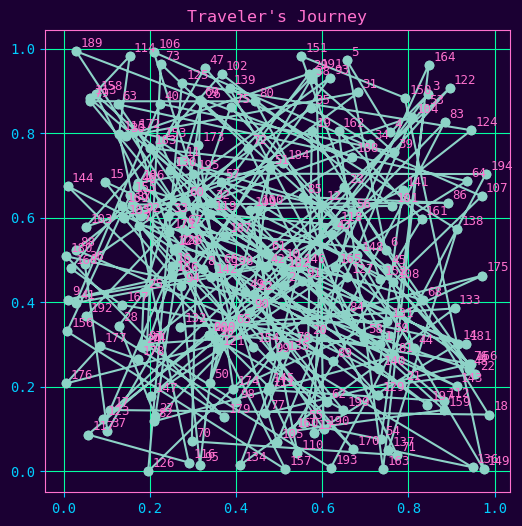

In [8]:
total_distance_randomize, route_randomize, total_distance_array_randomize, temperature_array_randomize = simulated_annealing(initial_temperature, alpha, number_of_iterations_of_thermalization, minimum_temperature, distances, 0)
print(total_distance_randomize)
print(route_randomize)
plot_tsp_problem(x, y, route_randomize)

21.09848422768097
[144, 175, 174, 24, 113, 71, 193, 114, 138, 136, 191, 7, 98, 74, 56, 16, 137, 173, 8, 58, 110, 124, 129, 169, 155, 171, 92, 17, 182, 67, 88, 76, 134, 145, 50, 112, 152, 94, 149, 118, 4, 6, 150, 162, 3, 86, 80, 53, 199, 2, 33, 165, 30, 192, 0, 97, 22, 48, 111, 146, 101, 41, 168, 21, 163, 176, 179, 153, 106, 187, 68, 64, 126, 130, 95, 122, 77, 181, 43, 157, 102, 178, 12, 123, 83, 148, 188, 26, 72, 1, 141, 23, 103, 142, 29, 25, 61, 66, 39, 177, 13, 120, 131, 159, 20, 90, 140, 170, 115, 161, 195, 133, 14, 184, 82, 172, 11, 183, 5, 47, 91, 125, 128, 189, 132, 32, 78, 196, 167, 151, 117, 154, 15, 60, 38, 143, 135, 40, 28, 59, 190, 139, 49, 79, 69, 84, 52, 44, 89, 81, 85, 160, 75, 104, 99, 107, 9, 158, 119, 87, 93, 194, 31, 116, 166, 18, 180, 63, 46, 108, 34, 19, 35, 27, 109, 121, 127, 37, 42, 105, 65, 164, 36, 186, 96, 100, 54, 62, 197, 156, 147, 51, 198, 73, 57, 45, 70, 10, 185, 55, 144]


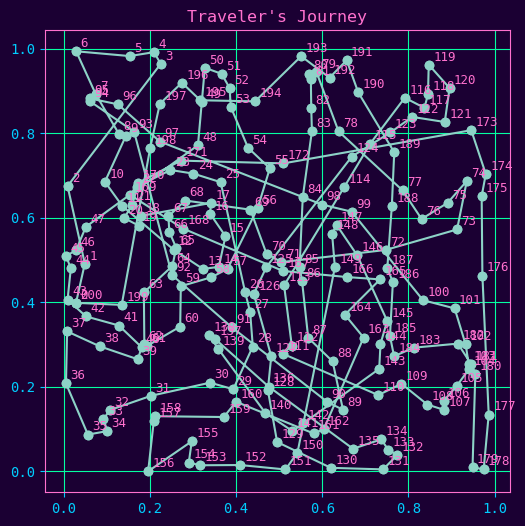

In [9]:
total_distance_swap, route_swap, total_distance_array_swap, temperature_array_swap = simulated_annealing(initial_temperature, alpha, number_of_iterations_of_thermalization, minimum_temperature, distances, 1)
print(total_distance_swap)
print(route_swap)
plot_tsp_problem(x, y, route_swap)

12.097952500768134
[66, 185, 142, 136, 138, 61, 114, 29, 25, 193, 71, 113, 24, 10, 70, 45, 2, 33, 165, 30, 192, 57, 12, 73, 102, 178, 157, 198, 51, 147, 11, 183, 5, 47, 91, 27, 125, 128, 189, 156, 172, 43, 123, 132, 82, 39, 89, 44, 177, 197, 181, 122, 95, 109, 121, 130, 77, 126, 52, 62, 18, 54, 13, 127, 120, 36, 131, 164, 159, 20, 65, 90, 37, 42, 105, 15, 60, 154, 38, 115, 170, 140, 161, 195, 79, 96, 186, 84, 100, 69, 116, 72, 26, 166, 180, 81, 148, 188, 184, 63, 64, 32, 68, 83, 35, 97, 22, 187, 48, 92, 78, 17, 23, 182, 196, 14, 133, 135, 167, 190, 139, 49, 194, 31, 141, 1, 143, 117, 85, 160, 151, 75, 87, 93, 67, 88, 59, 40, 28, 101, 41, 168, 4, 118, 134, 76, 119, 158, 107, 104, 99, 9, 50, 145, 112, 152, 94, 162, 144, 150, 149, 6, 55, 21, 175, 3, 86, 80, 53, 174, 191, 7, 110, 58, 8, 124, 108, 129, 34, 169, 19, 155, 106, 153, 179, 46, 176, 98, 163, 103, 146, 74, 111, 56, 16, 137, 173, 171, 0, 199, 66]


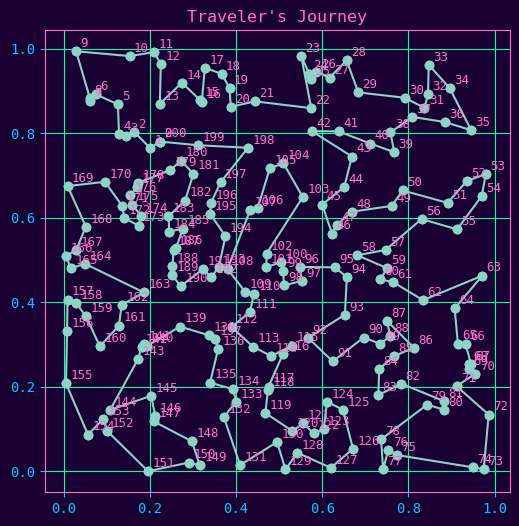

In [10]:
total_distance_inverse, route_inverse, total_distance_array_inverse, temperature_array_inverse = simulated_annealing(initial_temperature, alpha, number_of_iterations_of_thermalization, minimum_temperature, distances, 2)
print(total_distance_inverse)
print(route_inverse)
plot_tsp_problem(x, y, route_inverse)

Antes de concluir nada procedamos a obtener una tabla que en función del número de ciudades permita observar la distancia recorrida así como el tiempo tardado en resolver el problema para cada uno de los cuatro métodos:
<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-18eh{border-color:#000000;font-weight:bold;text-align:center;vertical-align:middle}
.tg .tg-wp8o{border-color:#000000;text-align:center;vertical-align:top}
.tg .tg-mqa1{border-color:#000000;font-weight:bold;text-align:center;vertical-align:top}
.tg .tg-mcqj{border-color:#000000;font-weight:bold;text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-18eh" rowspan="2">Número de ciudades</th>
    <th class="tg-mqa1" colspan="2">Closest Neighbour</th>
    <th class="tg-mqa1" colspan="2">Randomize</th>
    <th class="tg-mqa1" colspan="2">Swap</th>
    <th class="tg-mqa1" colspan="2">Invert</th>
  </tr>
  <tr>
    <th class="tg-mcqj">Tiempo (s) (± 0.1)</th>
    <th class="tg-mcqj">Distancia (± 0.01)</th>
    <th class="tg-mcqj">Tiempo (s) (± 0.1)</th>
    <th class="tg-mcqj">Distancia (± 0.01)</th>
    <th class="tg-mcqj">Tiempo (s) (± 0.1)</th>
    <th class="tg-mcqj">Distancia (± 0.01)</th>
    <th class="tg-mcqj">Tiempo (s) (± 0.1)</th>
    <th class="tg-mcqj">Distancia (± 0.01)</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-wp8o">10</td>
    <td class="tg-wp8o">0.0</td>
    <td class="tg-wp8o">3.60</td>
    <td class="tg-wp8o">0.5</td>
    <td class="tg-wp8o">4.29</td>
    <td class="tg-wp8o">0.3</td>
    <td class="tg-wp8o">3.15</td>
    <td class="tg-wp8o">0.4</td>
    <td class="tg-wp8o">3.15</td>
  </tr>
  <tr>
    <td class="tg-wp8o">20</td>
    <td class="tg-wp8o">0.0</td>
    <td class="tg-wp8o">4.35</td>
    <td class="tg-wp8o">0.7</td>
    <td class="tg-wp8o">8.84</td>
    <td class="tg-wp8o">0.4</td>
    <td class="tg-wp8o">4.14</td>
    <td class="tg-wp8o">0.5</td>
    <td class="tg-wp8o">4.14</td>
  </tr>
  <tr>
    <td class="tg-wp8o">30</td>
    <td class="tg-wp8o">0.0</td>
    <td class="tg-wp8o">5.54</td>
    <td class="tg-wp8o">1.0</td>
    <td class="tg-wp8o">12.17</td>
    <td class="tg-wp8o">0.5</td>
    <td class="tg-wp8o">4.66</td>
    <td class="tg-wp8o">0.6</td>
    <td class="tg-wp8o">4.62</td>
  </tr>
  <tr>
    <td class="tg-wp8o">40</td>
    <td class="tg-wp8o">0.0</td>
    <td class="tg-wp8o">5.55</td>
    <td class="tg-wp8o">1.3</td>
    <td class="tg-wp8o">17.74</td>
    <td class="tg-wp8o">0.6</td>
    <td class="tg-wp8o">5.58</td>
    <td class="tg-wp8o">0.8</td>
    <td class="tg-wp8o">5.20</td>
  </tr>
  <tr>
    <td class="tg-wp8o">50</td>
    <td class="tg-wp8o">0.1</td>
    <td class="tg-wp8o">7.73</td>
    <td class="tg-wp8o">1.6</td>
    <td class="tg-wp8o">22.89</td>
    <td class="tg-wp8o">0.7</td>
    <td class="tg-wp8o">7.05</td>
    <td class="tg-wp8o">0.9</td>
    <td class="tg-wp8o">5.99</td>
  </tr>
  <tr>
    <td class="tg-wp8o">100</td>
    <td class="tg-wp8o">0.7</td>
    <td class="tg-wp8o">8.76</td>
    <td class="tg-wp8o">3.1</td>
    <td class="tg-wp8o">47.94</td>
    <td class="tg-wp8o">1.3</td>
    <td class="tg-wp8o">11.85</td>
    <td class="tg-wp8o">1.4</td>
    <td class="tg-wp8o">8.17</td>
  </tr>
  <tr>
    <td class="tg-wp8o">200</td>
    <td class="tg-wp8o">9.2</td>
    <td class="tg-wp8o">13.09</td>
    <td class="tg-wp8o">6.3</td>
    <td class="tg-wp8o">96.09</td>
    <td class="tg-wp8o">2.4</td>
    <td class="tg-wp8o">21.44</td>
    <td class="tg-wp8o">2.8</td>
    <td class="tg-wp8o">11.73</td>
  </tr>
</tbody></table>

Se pueden hacer las siguientes observaciones de la anterior tabla:
- El método más efectivo a la hora de resolver el problema es si ninguna duda el "simulated annealing" utilizando el método de "inverse". Este consigue resultados de la resolución de el TSP muy buenos para todos los números de ciudades evaluadas, llegando a estos en tiempo muy corto. Este será el método con el que compararemos el resto de resultados.

- El segundo método más efectivo es el "Closest Neighobour Algorithm", el cual consigue resultados de distancia recorrida ligeramente superiores al método anterior y de una manera más rápida que este último (a excepción de cuando aumentamos significativamente el número de ciudades, ya que para 200 ciudades triplica el tiempo que tarda el "inverse").

- El tercer método más efectivo es el que emplea el método "swap" como parte del algoritmo de "simulated annealing", consiguiendo resultados ligeramente más rápidos que en el caso de "inverse", pero significativamente peores en cuanto a la evaluación de la distancia recorrida. Concretamente se ha de señalar que el empeoramiento es mucho más grande entre este método y el "Closest Neighbour" que entre los otros dos anteriormente evaluados, llegando a duplicar la distancia total recorrida.

- Por último, el peor método con significativa diferencia es el "randomize", el cual no es un buen candidato en ninguna ocasión para resolver el TSP.

Para realizar una comparativa de la convergencia de los métodos de "simulated annealing" evaluados se va a hacer dos gráficas, una conteniendo la evolución de la distancia total recorrida en la resolución del problema y otra conteniendo la evolución de la temperatura, ambas en función del número de iteraciones llevadas a cabo.

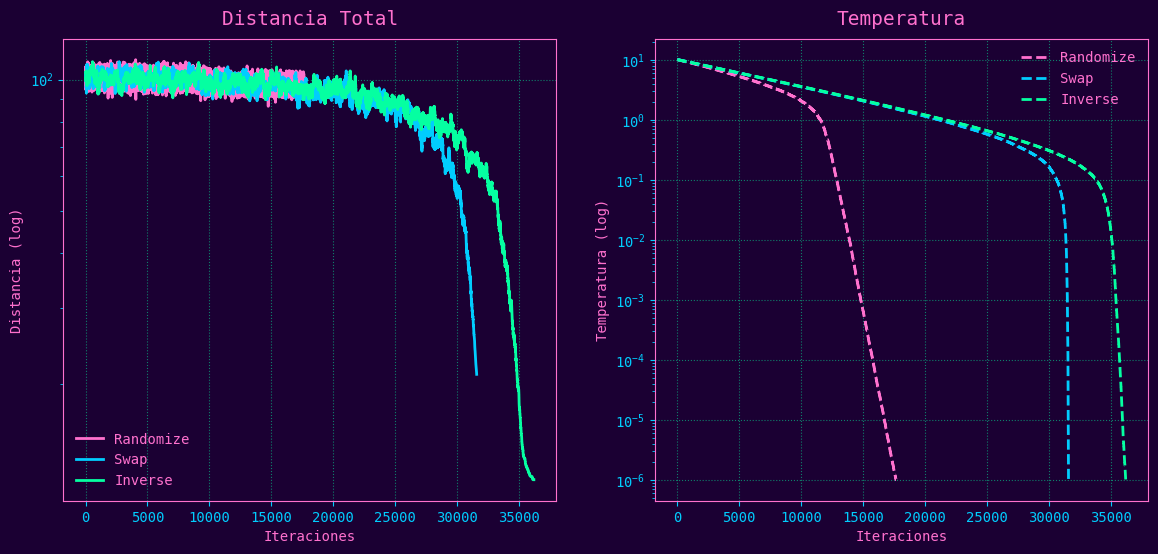

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Distancia
axs[0].plot(total_distance_array_randomize, color="#ff71ce", linewidth=2, label="Randomize")
axs[0].plot(total_distance_array_swap, color="#01cdfe", linewidth=2, label="Swap")
axs[0].plot(total_distance_array_inverse, color="#05ffa1", linewidth=2, label="Inverse")

axs[0].set_yscale("log")
axs[0].set_title("Distancia Total", fontsize=14, pad=10)
axs[0].set_xlabel("Iteraciones")
axs[0].set_ylabel("Distancia (log)")
axs[0].grid(True, linestyle=":", alpha=0.5)
axs[0].legend(frameon=False)

# Temperatura
axs[1].plot(temperature_array_randomize, color="#ff71ce", linestyle="--", linewidth=2, label="Randomize")
axs[1].plot(temperature_array_swap, color="#01cdfe", linestyle="--", linewidth=2, label="Swap")
axs[1].plot(temperature_array_inverse, color="#05ffa1", linestyle="--", linewidth=2, label="Inverse")

axs[1].set_yscale("log")
axs[1].set_title("Temperatura", fontsize=14, pad=10)
axs[1].set_xlabel("Iteraciones")
axs[1].set_ylabel("Temperatura (log)")
axs[1].grid(True, linestyle=":", alpha=0.5)
axs[1].legend(frameon=False)

plt.show()

Podemos obtener a partir de estas gráficas una serie de conclusiones sobre el comportamiento general del algoritmo simulated annealing:
- El algoritmo comienza con distancias altas y mejora de forma lenta y ruidosa, lo cual indica una fase de exploración correcta.
- Al final de la ejecución se observa una caída brusca de la distancia coincidiendo con temperaturas muy bajas, lo que marca la fase de explotación.
- Este comportamiento es el esperado en "simulated annealing" y confirma que se ha programado correctamente.

Si nos fijamos en los distintos métodos empleados en cada caso:
- Para "randomize":
    - Converge más rápido.
    - Enfriamiento agresivo.
    - Obtiene soluciones finales de menor calidad.

- Para "swap":
    - Exploración con menor desviación respecto a la media.
    - Convergencia más tardía.
    - Resultados intermedios en calidad al compararlo con los otros dos métodos.

- Para "inverse":
    - Mejores soluciones finales (menor distancia).
    - Mejora más estable y estructurada, con menos fluctuaciones con respecto a la media en el proceso de exploración.
    - Preserva relaciones locales importantes.
    - Operador más adecuado para este problema.

Si nos fijamos en la gráfica de la temperatura se puede concluir:
- "Randomize" presenta un enfriamiento rápido, lo que explica su convergencia temprana.
- "Swap" e "inverse" mantienen temperaturas altas durante más tiempo, favoreciendo la exploración.
- La mejora significativa de la distancia ocurre cuando la temperatura cae por debajo de valores bajos.

Por lo tanto, las conclusiones finales sobre este algoritmo son:
- El algoritmo funciona correctamente y muestra una transición clara de exploración a explotación.
- Ranking de operadores:
  1. **"Inverse"**
  2. **"Swap"**
  3. **"Randomize"**
- La combinación más efectiva es **"inverse" con un enfriamiento lento**.